In [1]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'[{_str}]:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

In [2]:
%%capture
!pip -q install lightning torchinfo

# RNN Model Design (Char-RNN)

## **Import Module**

In [3]:
import torch
from torch import nn
from torch.nn import functional as F
from torchmetrics import functional as FM
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import v2
import torchvision
from torchinfo import summary

import lightning as L
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

device ='cuda:0'
torch.__version__,L.__version__

('2.8.0+cu126', '2.5.5')

## **DataSet**

### 학습할 문장 만들기

In [4]:
# 학습할 문장
sentence = ("if you want to build a ship, don't drum up people together to "
            "collect wood and don't assign them tasks and work, but rather "
            "teach them to long for the endless immensity of the sea.")
print ("FOLLOWING IS OUR TRAINING SEQUENCE:")
print (sentence)
print ("Length of 'test sentence' is %s" %len(sentence))

FOLLOWING IS OUR TRAINING SEQUENCE:
if you want to build a ship, don't drum up people together to collect wood and don't assign them tasks and work, but rather teach them to long for the endless immensity of the sea.
Length of 'test sentence' is 180


### 입력 문자열과 타겟 문자 준비

In [5]:
# make charater dictionary
char_set = list(set(sentence)) # char set 생성
char_dic = {w: i for i, w in enumerate(char_set)}
print ("CHARACTERS: ")
print (len(char_set))
print (char_set)
print ("DICTIONARY: ")
print (len(char_dic))
print (char_dic)

CHARACTERS: 
25
['.', 'e', 's', 'a', 't', 'u', 'k', 'b', 'o', 'f', 'h', 'd', 'y', 'n', 'r', 'p', 'l', 'w', 'g', 'c', 'i', 'm', "'", ',', ' ']
DICTIONARY: 
25
{'.': 0, 'e': 1, 's': 2, 'a': 3, 't': 4, 'u': 5, 'k': 6, 'b': 7, 'o': 8, 'f': 9, 'h': 10, 'd': 11, 'y': 12, 'n': 13, 'r': 14, 'p': 15, 'l': 16, 'w': 17, 'g': 18, 'c': 19, 'i': 20, 'm': 21, "'": 22, ',': 23, ' ': 24}


In [6]:
data_dim    = len(char_set) # train data X:input
num_classes = len(char_set) # trian data Y:target
sequence_length = 10        # any arbitrary number
features = 1                # X,Y index
print ('data_dim : %d' %data_dim)
print ('num_classes : %d' %num_classes)

data_dim : 25
num_classes : 25


In [7]:
dataX = []  # input sequence list
dataY = []  # target sequence list

# we will make 170 sequences
for i in range(0, len(sentence) - sequence_length):
    # 10 characters = 1 training sequence
    x_str = sentence[i : i+sequence_length]
    y_str = sentence[i+1 : i+sequence_length+1]
    # convert x, y str to index(int)
    x_idx = [char_dic[c] for c in x_str]
    y_idx = [char_dic[c] for c in y_str]
    # append to dataset list
    dataX.append(x_idx)
    dataY.append(y_idx)

    # monitoring
    if i<5:
        print ("[%3d/%3d] [%s]=>[%s]" % (i, len(sentence), x_str, y_str))
        print ("%s%s=>%s" % (' '*10, x_idx, y_idx))

[  0/180] [if you wan]=>[f you want]
          [20, 9, 24, 12, 8, 5, 24, 17, 3, 13]=>[9, 24, 12, 8, 5, 24, 17, 3, 13, 4]
[  1/180] [f you want]=>[ you want ]
          [9, 24, 12, 8, 5, 24, 17, 3, 13, 4]=>[24, 12, 8, 5, 24, 17, 3, 13, 4, 24]
[  2/180] [ you want ]=>[you want t]
          [24, 12, 8, 5, 24, 17, 3, 13, 4, 24]=>[12, 8, 5, 24, 17, 3, 13, 4, 24, 4]
[  3/180] [you want t]=>[ou want to]
          [12, 8, 5, 24, 17, 3, 13, 4, 24, 4]=>[8, 5, 24, 17, 3, 13, 4, 24, 4, 8]
[  4/180] [ou want to]=>[u want to ]
          [8, 5, 24, 17, 3, 13, 4, 24, 4, 8]=>[5, 24, 17, 3, 13, 4, 24, 4, 8, 24]


**입력문자 index의 list를 ndarrary로 변환**

In [8]:
X = np.array(dataX)   # ndarray(170,10)<-[170,10]
X = np.reshape(X,(X.shape[0],X.shape[1],features))
ps(X,'X') # (170,10,1)

# Target tensor 생성 # ndarray(170,10,1)<-[170,10]
Y = np.array(dataY)   # (170,10)<-[170,10]
Y = Y= np.reshape(Y,(Y.shape[0],Y.shape[1],features))
ps(Y,'Y') # (170,10,1)

Y1 = np.array(dataY)[:,-1]  # 마지막 문자만, (170,)<-[170,10]
Y1= np.reshape(Y1,(Y1.shape[0],features)) # (170,1)
ps(Y1,'Y1') # (170,1)

[X] Shape(170, 10, 1)
[Y] Shape(170, 10, 1)
[Y1] Shape(170, 1)


* 행렬: [ 1 2 3 ]
* 벡터: (1,2,3)
* list:[1,2,3]
* ndarray : arrary(list) (= n-dim 행렬)

In [9]:
na = np.array([1,2,3,4,5])
print(na)                   # value를 print
na                          # 무엇인지 보여줌(contents)

[1 2 3 4 5]


array([1, 2, 3, 4, 5])

In [ ]:
list_ = [1,2,3,4,5]
# list는 shape을 표현할 수 없음(행렬이 아님)
p(list_)                   # [1,2,3,4,5]         shape(x)
na = np.array(list_)
p(na)                      # [1 2 3 4 5]         (5,)
p(np.reshape(na,(5,1)))    # [[1][2][3][4][5]]   (5,1)
p(np.reshape(na,(1,5)))    # [[1 2 3 4 5]]       (1,5)
p(np.reshape(na,(1,5,1)))  # [[[1][2][3][4][5]]] (1,5,1)
p(np.reshape(na,(1,5,1,1)))# [[[[1]][[2]][[3]][[4]][[5]]]]
p(np.reshape(na,(1,1,5,1)))# [[[[1][2][3][4][5]]]]
p(np.squeeze(np.reshape(na,(1,5,1))))# [1 2 3 4 5] (5,)

### Define CustormDataset

In [10]:
class CustomDataset(Dataset):
    def __init__(self, x, y):
        super().__init__()
        self.x = x
        self.y = y
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return torch.FloatTensor(self.x[idx]), torch.FloatTensor(self.y[idx])

trainDataset = CustomDataset(X, Y1)
trainDataLoader = DataLoader(trainDataset, shuffle=True,
                             drop_last=False, batch_size=1)

trainDataset_many = CustomDataset(X, Y)
trainDataLoader_many = DataLoader(trainDataset_many, shuffle=True,
                                  drop_last=False, batch_size=1)

## **Model-1** : many to one model

### Define

In [11]:
#num_classes = len(char_set) # trian data Y:target
#features = 1                # X,Y index
hidden_dim = 75

class ManyToOneLSTM(L.LightningModule):
    def __init__(self, batch_first=True):
        super(ManyToOneLSTM, self).__init__()
        self.lstm = nn.LSTM(features, hidden_dim,
                            batch_first=batch_first)
        self.linear = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        out, (hn, cn) = self.lstm(x)    #(bs,timesteps,units)
        out = self.linear(out[:, -1, :])#(bs,num_classes)<-(bs,units)
        return out

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)       #(bs, num_classes)
        y = y.squeeze(dim=-1) #(bs,)<-(bs,1)
        loss = F.cross_entropy(y_hat, y.long())
        acc = FM.accuracy(y_hat, y, task='multiclass', num_classes=25 )
        metrics = {'loss':loss, 'acc':acc}
        self.log_dict(metrics,prog_bar=True,on_step=False,on_epoch=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters())

model = ManyToOneLSTM()

inputs = torch.zeros(2,sequence_length,features)
output = model(inputs) #(2,25)
ps(output)
summary(model, input_size=(2, sequence_length, features)) #(4,10,1)

[] Shapetorch.Size([2, 25])


Layer (type:depth-idx)                   Output Shape              Param #
ManyToOneLSTM                            [2, 25]                   --
├─LSTM: 1-1                              [2, 10, 75]               23,400
├─Linear: 1-2                            [2, 25]                   1,900
Total params: 25,300
Trainable params: 25,300
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.47
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.10
Estimated Total Size (MB): 0.11

In [ ]:
#torch.onnx.export(model.cpu(), inputs, 'CharRNN-1.onnx')

### Fit

In [12]:
from lightning.pytorch.callbacks import ModelCheckpoint

In [13]:
%%time
model = ManyToOneLSTM()
name = "ManyToOneLSTM"

checkpoint_callback = ModelCheckpoint(dirpath='./aicamp', monitor='loss')
logger = CSVLogger("logs", name=name)
trainer = Trainer(max_epochs=200, logger=logger,callbacks=[checkpoint_callback])
trainer.fit(model, trainDataLoader)

checkpoint = torch.load(checkpoint_callback.best_model_path)
model.load_state_dict(checkpoint['state_dict'])
model.eval()
# Wall time: 2min 20s

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO:lightning.pytorch.utilities.rank_zero:You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more det

Training: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=200` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=200` reached.


CPU times: user 2min 28s, sys: 1.76 s, total: 2min 30s
Wall time: 2min 30s


ManyToOneLSTM(
  (lstm): LSTM(1, 75, batch_first=True)
  (linear): Linear(in_features=75, out_features=25, bias=True)
)

In [14]:
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')
df = history.groupby('epoch').last().drop('step', axis=1)

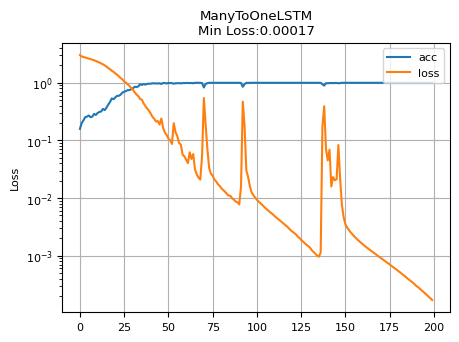

In [15]:
plt.title(f"{name}\nMin Loss:{df['loss'].min():.5f}")
plt.plot(df['acc'], label='acc')
plt.plot(df['loss'], label='loss')
plt.semilogy()
plt.grid()
plt.legend()
plt.ylabel('Loss')
plt.legend()
plt.show()

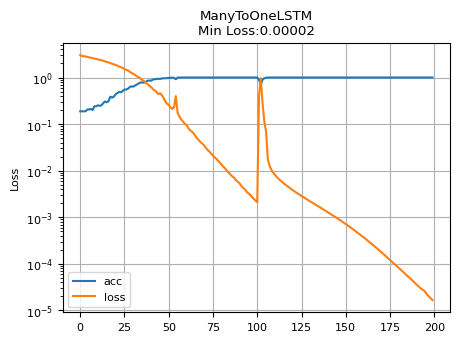

### **Generate Text:** analysis

#### Define generate_seq function

In [17]:
# 문자열 생성하기
def generate_seq(model, char_dic, seq_length, seed_text, n_chars):
    in_text = seed_text    # seed 문자열 + 생성 문자
    # 생성할 문자열의 수 = n_chars
    for i in range(n_chars):
        # 문자 encode : 문자 -> int
        encoded = [char_dic[char] for char in in_text]
        # 뒷부분 10자만 사용
        encoded = encoded[-sequence_length:]
        encoded = np.array(encoded)
        # Tensor(1,10,1) <- np(1,10)
        encoded = torch.FloatTensor(np.reshape(encoded,(1,seq_length,1)))
        # 다음문자 추론
        model.eval()
        yhat = model(encoded)  # yhat.shape=(1,25): class 확률
        yhat = np.argmax(yhat.detach().numpy(), axis=1) # index <- pb.
        # 문자 디코딩 : integer -> character
        for char, index in char_dic.items():
            if index == yhat:
                break
        in_text += char    # 문자열에 추가
    return in_text

#### Generate a sequence of characters

학습문장: if you want to build a ship, don't drum up people together to collect wood and don't assign them tasks and work, but rather teach them to long for the endseed_textnsity of the sea.

In [18]:
# test start of rhyme
print('Trigger characters: "want to bu "\nResult: \n"{}"'.format(
      generate_seq(model, char_dic, sequence_length, 'want to bu', 200)))
# test mid-line
print('\nTrigger characters: "collect wo"\nResult: \n"{}"'.format(
      generate_seq(model, char_dic, sequence_length, 'collect wo', 200)))
# test not in original
print('\nTrigger characters: "abbcr than"\nResult: "{}"'.format(
      generate_seq(model, char_dic, sequence_length, 'abbcr than', 200)))

Trigger characters: "want to bu "
Result: 
"want to build a ship, don't drum up people together to collect wood and don't assign them tasks and work, but rather teach them to long for the endless immensity of the sea.a.a andrwouk, tathr themtndless immen"

Trigger characters: "collect wo"
Result: 
"collect wood and don't assign them tasks and work, but rather teach them to long for the endless immensity of the sea.a.a andrwouk, tathr themtndless immensity of the sea.a.a andrwouk, tathr themtndless immensi"

Trigger characters: "abbcr than"
Result: "abbcr than tasks and work, but rather teach them to long for the endless immensity of the sea.a.a andrwouk, tathr themtndless immensity of the sea.a.a andrwouk, tathr themtndless immensity of the sea.a.a andrwo"


- **epoch 200**

Trigger characters: "want to bu "
Result:
"want to build a ship, don't drum up people together to collect wood and don't assign them tasks and work, but rather teach them to long for the endless immensity of the sea. eon wood and don't assign them tasks"

Trigger characters: "collect wo"
Result:
"collect wood and don't assign them tasks and work, but rather teach them to long for the endless immensity of the sea. eon wood and don't assign them tasks and work, but rather teach them to long for the endles"

Trigger characters: "abbcr than"
Result: "abbcr thanhimttaagh them to long for the endless immensity of the sea. eon wood and don't assign them tasks and work, but rather teach them to long for the endless immensity of the sea. eon wood and don't assig"

=====


- **epoch 50**

Trigger characters: "want to bu "
Result:  "want to build a ship, don't dr't assign them tosss and work, but r ather  teoohimm for the tearp,
ton ther te chlthem tosss and work, but rather
teoohimm   for the tearp, ton ther te chlthem tosss and work, but rat"

Trigger characters: "collect wo"
Result:
"collect wood and dossig butpo pe to build a ship, don't dr't assign them
tosss and work, but rather
teoohimm for the tearp, ton ther te chlthem tosss and work, but rather teoohimm for the tearp, ton ther te chl"

Trigger characters: "aabbcr than"
Result: "abbcr than'thossign them tosss and work, but rather teoohimm for the
 tearp, ton ther te chlthem
 tosss and work, but rather teoohimm for the tearp, ton ther te chlthem tosss and work, but rather teoohimm for the"


## **Model-2** : many to many model

### Define

In [19]:
#num_classes = len(char_set) # trian data Y:target
#features = 1                # X,Y index
hidden_dim = 75
class ManyToManyLSTM(L.LightningModule):
    def __init__(self, batch_first=True):
        super(ManyToManyLSTM, self).__init__()
        self.lstm = nn.LSTM(features, hidden_dim, batch_first=batch_first)
        self.linear = nn.Linear(hidden_dim, num_classes) #(bs,10,25)

    def forward(self, x):
        out, (hn, cn) = self.lstm(x)
        out = self.linear(out)
        return out #(bs,10,25)

    def training_step(self, batch, batch_idx):
        x, y = batch    # y:(bs,10,1)
        y_hat = self(x) # (bs,10,25)
        y = y.squeeze(dim=-1) #(bs,10)
        loss = acc = 0.0
        for i in range(x.shape[1]): # seq.에 대한 평균 구하기
            loss += F.cross_entropy(y_hat[:, i, :], y[:, i].long())
            acc += FM.accuracy(y_hat[:, i, :], y[:, i],task='multiclass', num_classes=num_classes )
        loss /= sequence_length
        acc /= sequence_length
        metrics={'loss':loss, 'acc':acc}
        self.log_dict(metrics,prog_bar=True,on_step=False,on_epoch=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters())

model = ManyToManyLSTM()
summary(model, input_size=(2, sequence_length, features))

Layer (type:depth-idx)                   Output Shape              Param #
ManyToManyLSTM                           [2, 10, 25]               --
├─LSTM: 1-1                              [2, 10, 75]               23,400
├─Linear: 1-2                            [2, 10, 25]               1,900
Total params: 25,300
Trainable params: 25,300
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.47
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 0.10
Estimated Total Size (MB): 0.12

### Fit

In [20]:
%%time
model = ManyToManyLSTM()
name = "ManyToManyLSTM"

checkpoint_callback = ModelCheckpoint(dirpath='./aicamp', monitor='loss')
logger = CSVLogger("logs", name=name)
trainer = Trainer(max_epochs=200, logger=logger,callbacks=[checkpoint_callback])
trainer.fit(model, trainDataLoader_many)

checkpoint = torch.load(checkpoint_callback.best_model_path)
model.load_state_dict(checkpoint['state_dict'])
model.eval()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:751: Checkpoint directory /content/aicamp exists and is not empty.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name   | Type   | Params | Mode 
------------------------------------------
0 | lstm   | LSTM   | 23.4 K | train
1 | linear | Linear | 1.9 K  | train
------------------------------------------
25.3 K    Trainable params
0         Non-trainable params
25.3 K    Total params
0.101     Total estimated model params size (MB)
2

Training: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=200` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=200` reached.


CPU times: user 5min 57s, sys: 1.72 s, total: 5min 59s
Wall time: 5min 59s


ManyToManyLSTM(
  (lstm): LSTM(1, 75, batch_first=True)
  (linear): Linear(in_features=75, out_features=25, bias=True)
)

Wall time: 6min 3s

In [21]:
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')
df = history.groupby('epoch').last().drop('step', axis=1)

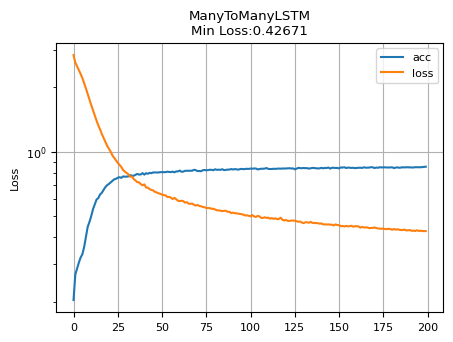

In [22]:
plt.title(f"{name}\nMin Loss:{df['loss'].min():.5f}")
plt.plot(df['acc'], label='acc')
plt.plot(df['loss'], label='loss')
plt.semilogy()
plt.grid()
plt.legend()
plt.ylabel('Loss')
plt.legend()
plt.show()

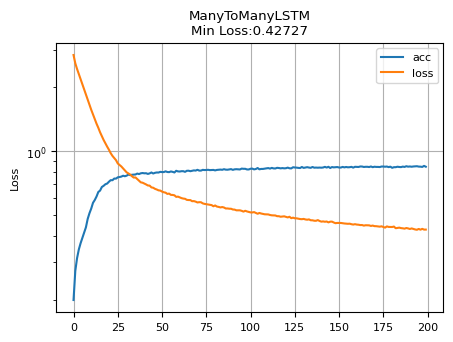

### **Generate Text:** analysis

##### Define generate_seq function

- 10개의 출력 시퀀스를 받으므로 수정 필요

In [23]:
# 문자열 생성하기
def generate_seq2(model, char_dic, seq_length, seed_text, n_chars):
    in_text = seed_text									# seed 문자열 + 생성 문자
    # 생성할 문자열의 수 = n_chars
    for i in range(n_chars):
        # 문자 encode : 문자 -> int
        encoded = [char_dic[char] for char in in_text]
        # 문자열 크기 조정 : max보다 크면 앞부분 제거
        encoded = encoded[-sequence_length:]
        encoded = np.array(encoded)
        # Tensor(1,10,1) <- np(1,10)
        encoded = torch.FloatTensor(np.reshape(encoded,(1,seq_length,1)))
        # 다음문자 추론
        yhat = model(torch.FloatTensor(encoded))  ## yhat.shape=(1,10,25):확률 시퀀스
        prob = F.softmax(yhat[0,9],dim=0)         ## logit to prob
        prob_list.append(np.max(prob.cpu().detach().numpy())) # 가장 큰 확률값을 append
        yhat = np.argmax(yhat.cpu().detach().numpy(), axis=2) # 확률 중에서 가장 큰 값의 위치 (1,10,1)<(1,10,25)
        yhat = np.squeeze(yhat)        # (10,) <- (1,10,1)
        # 문자 디코딩 : integer -> character
        for char, index in char_dic.items():
            if index == yhat[9]:         # 시퀀스에서 마지막 값을 사용
                break
        in_text += char    # 문자열에 추가
    return in_text

##### Generate a sequence of characters

학습문장: if you want to build a ship, don't drum up people together to collect wood and don't assign them tasks and work, but rather teach them to long for the endless immensity of the sea.

In [24]:
probs = []
prob_list =[]
# test start of rhyme
print('Trigger characters: "want to bu "\nResult: \n"{}"'.format(
      generate_seq2(model, char_dic, sequence_length, 'want to bu', 200)))
probs.append(np.array(prob_list))

prob_list =[]
# test mid-line
print('\nTrigger characters: "collect wo"\nResult: \n"{}"'.format(
      generate_seq2(model, char_dic, sequence_length, 'collect wo', 200)))
probs.append(np.array(prob_list))

prob_list =[]
# test not in original
print('\nTrigger characters: "aabbcr than"\nResult: "{}"'.format(
      generate_seq2(model, char_dic, sequence_length, 'abbcr than', 200)))
probs.append(np.array(prob_list))

Trigger characters: "want to bu "
Result: 
"want to build a ship, don't drum up people together to collect wood and don't assign them tasks and work, but rather teach them to long for the endless immensity of the sea. immensity of the sea. immensity of t"

Trigger characters: "collect wo"
Result: 
"collect wood and don't assign them tasks and work, but rather teach them to long for the endless immensity of the sea. immensity of the sea. immensity of the sea. immensity of the sea. immensity of the sea. imm"

Trigger characters: "aabbcr than"
Result: "abbcr than to collect wood and don't assign them tasks and work, but rather teach them to long for the endless immensity of the sea. immensity of the sea. immensity of the sea. immensity of the sea. immensity o"


Trigger characters: "want to bu "
Result:
"want to build a ship, don't drum up people together to collect wood and don't assign them tasks and work, but rather teach them to long for the endless immensity of the sea.ddon't assign them tasks and work, bu"

Trigger characters: "collect wo"
Result:
"collect wood and don't assign them tasks and work, but rather teach them to long for the endless immensity of the sea.ddon't assign them tasks and work, but rather teach them to long for the endless immensity o"

Trigger characters: "aabbcr than"
Result: "abbcr than tasks and work, but rather teach them to long for the endless immensity of the sea.ddon't assign them tasks and work, but rather teach them to long for the endless immensity of the sea.ddon't assign "

- **epoch 200**

Trigger characters: "want to bu "
Result:
"want to build a ship, don't drum up people together to collect wood and don't assign them tasks and work, but rather teach them to long for the endless immensity of the sea.ddon't assign them tasks and work, bu"

Trigger characters: "collect wo"
Result:
"collect wood and don't assign them tasks and work, but rather teach them to long for the endless immensity of the sea.ddon't assign them tasks and work, but rather teach them to long for the endless immensity o"

Trigger characters: "aabbcr than"
Result: "abbcr than tasks and work, but rather teach them to long for the endless immensity of the sea.ddon't assign them tasks and work, but rather teach them to long for the endless immensity of the sea.ddon't assign "
